# Slum Area Classification — Multi-Source Remote Sensing Model

Binary classification of **Slum (1)** vs **Non-Slum (0)** at the *kelurahan* level across
four Indonesian cities (Ambon, DKI Jakarta, Kebumen, Samarinda) using **XGBoost**.

The model fuses three complementary remote-sensing sources:

- **Building footprint** morphology (Google Open Buildings) — size, density, height, coverage.
- **Built-up spectral + texture** indices (Sentinel-2 NDBI and its GLCM texture).
- **Radar backscatter** (Sentinel-1 VV/VH) and **optical context** (NDVI, BSI, brightness).

### Pipeline at a glance
1. Load the per-kelurahan feature table and define the predictive feature groups.
2. Explore the data: class balance, feature relationships, spatial patterns.
3. Validate with **Leave-One-City-Out (LOCO)** cross-validation to measure how well the
   model generalizes to a city it has not seen during training.
4. Report imbalance-aware performance, inspect feature importance, and map predicted risk.

## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from IPython.display import display

from sklearn.model_selection import LeaveOneGroupOut, GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, confusion_matrix,
                             average_precision_score, roc_auc_score, roc_curve,
                             precision_recall_curve, accuracy_score, f1_score,
                             precision_score, recall_score)
from xgboost import XGBClassifier
import shap

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')
PALETTE = {0: '#2ecc71', 1: '#e74c3c'}

## 2. Data Loading & Feature Definition

The feature table holds one row per kelurahan. Predictive features are organized into four
source groups. Identifier and grouping columns (`unit_id`, `unit_area_m2`, `city`) are kept
separate from the model inputs: `city` defines the spatial grouping used by cross-validation,
while `unit_id` and `unit_area_m2` are metadata used for joining and reference only.

In [3]:
df = pd.read_csv('../data/processed/features_buildings.csv')

META = ['slum', 'city', 'unit_id', 'unit_area_m2']

CORE_BUILDING = [
    'b_area_mean', 'b_area_median', 'b_area_std', 'b_area_sum',
    'b_count', 'b_coverage', 'b_density_km2', 'b_size_cv',
    'building_fractional_count_mean', 'building_fractional_count_stdDev',
    'building_height_mean', 'building_height_stdDev',
    'building_presence_mean', 'building_presence_stdDev',
]
NDBI_BUILTUP = [
    'ndbi_mean', 'ndbi_stdDev', 'ndbi_contrast_mean', 'ndbi_contrast_stdDev',
    'ndbi_ent_mean', 'ndbi_ent_stdDev', 'ndbi_var_mean', 'ndbi_var_stdDev',
]
SAR_SENTINEL1 = ['VH_mean', 'VH_stdDev', 'VV_mean', 'VV_stdDev', 'vv_vh_mean', 'vv_vh_stdDev']
OPTICAL_INDICES = ['brightness_mean', 'brightness_stdDev', 'bsi_mean', 'bsi_stdDev',
                   'ndvi_mean', 'ndvi_stdDev']

GROUPS = {
    'Building footprint (Google Open Buildings)': CORE_BUILDING,
    'NDBI built-up + texture (Sentinel-2)': NDBI_BUILTUP,
    'SAR radar (Sentinel-1)': SAR_SENTINEL1,
    'Optical indices (Sentinel-2)': OPTICAL_INDICES,
}

FEATURES = [c for c in (CORE_BUILDING + NDBI_BUILTUP + SAR_SENTINEL1 + OPTICAL_INDICES)
            if c in df.columns]
feat_group = {f: g for g, cols in GROUPS.items() for f in cols}

y = df['slum'].astype(int).values
groups = df['city'].values

overview = pd.DataFrame({
    'group': list(GROUPS.keys()) + ['TOTAL'],
    'n_features': [len([c for c in cols if c in df.columns]) for cols in GROUPS.values()]
                  + [len(FEATURES)],
})
display(overview)
display(pd.Series({
    'n_samples': len(y), 'n_slum': int(y.sum()),
    'prevalence': round(float(y.mean()), 4), 'n_cities': int(len(np.unique(groups))),
}).to_frame('value'))

,group,n_features
0,Building footprint (Google Open Buildings),14
1,NDBI built-up + texture (Sentinel-2),8
2,SAR radar (Sentinel-1),6
3,Optical indices (Sentinel-2),6
4,TOTAL,34


,value
n_samples,828.0000
n_slum,118.0000
prevalence,0.1425
n_cities,4.0000


## 3. Exploratory Data Analysis

Each visualization below is framed by the question it is meant to answer, so the analysis
reads as a guided investigation of the data.

### 3.1 Class balance and per-city prevalence
**Question:** How many kelurahan are slums versus non-slums, and does the slum rate differ
from city to city? This sets the imbalance level and motivates city-aware validation.

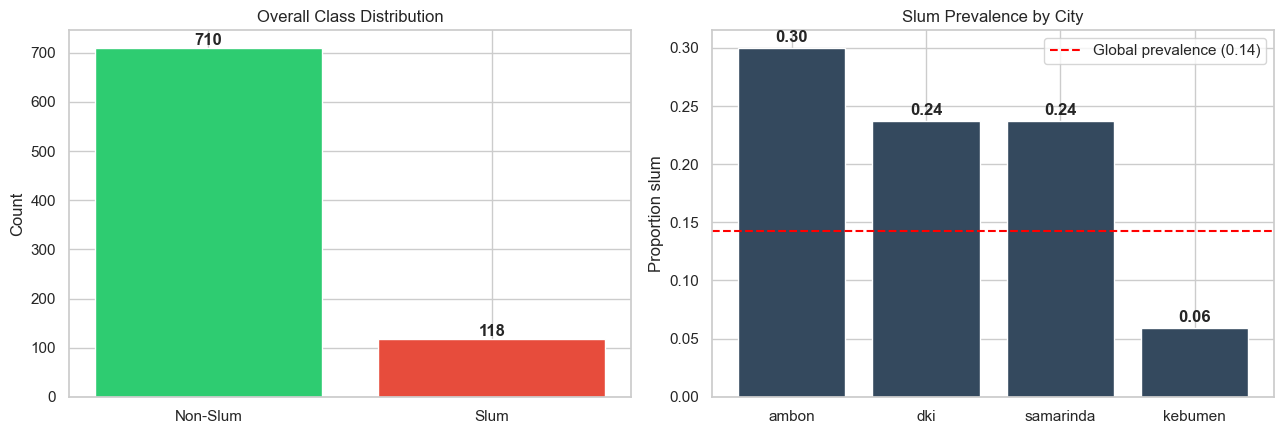

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

counts = pd.Series(y).map({0: 'Non-Slum', 1: 'Slum'}).value_counts()
ax[0].bar(counts.index, counts.values, color=[PALETTE[0], PALETTE[1]])
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
ax[0].set_title('Overall Class Distribution')
ax[0].set_ylabel('Count')

prev = df.groupby('city')['slum'].mean().sort_values(ascending=False)
ax[1].bar(prev.index, prev.values, color='#34495e')
ax[1].axhline(y.mean(), ls='--', color='red', label=f'Global prevalence ({y.mean():.2f})')
for i, v in enumerate(prev.values):
    ax[1].text(i, v + 0.005, f'{v:.2f}', ha='center', fontweight='bold')
ax[1].set_title('Slum Prevalence by City')
ax[1].set_ylabel('Proportion slum')
ax[1].legend()
plt.tight_layout()
plt.show()

### 3.2 Which features relate to slum status?
**Question:** Which individual features show the strongest linear association with the slum
label, and which data source do they come from? Bars are colored by source group.

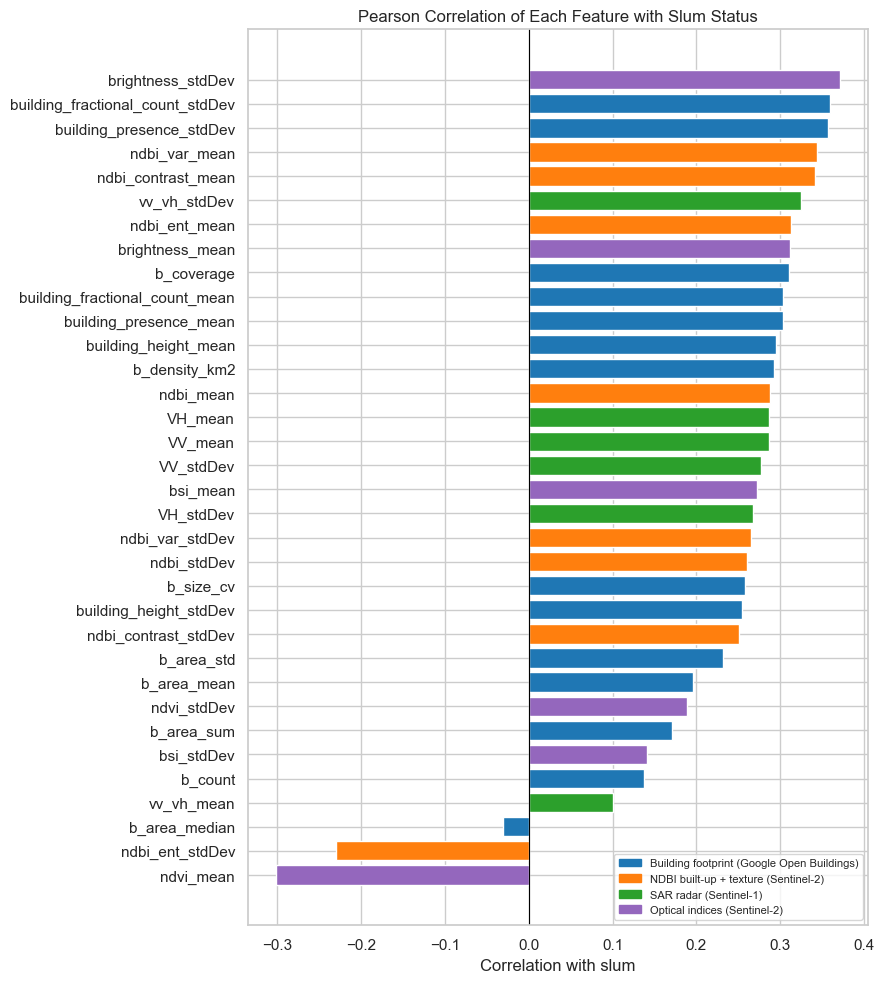

In [5]:
corr = df[FEATURES + ['slum']].corr()['slum'].drop('slum').sort_values()
colors_map = {
    'Building footprint (Google Open Buildings)': '#1f77b4',
    'NDBI built-up + texture (Sentinel-2)': '#ff7f0e',
    'SAR radar (Sentinel-1)': '#2ca02c',
    'Optical indices (Sentinel-2)': '#9467bd',
}
bar_colors = [colors_map[feat_group[f]] for f in corr.index]

plt.figure(figsize=(9, 10))
plt.barh(corr.index, corr.values, color=bar_colors)
plt.axvline(0, color='black', lw=0.8)
plt.title('Pearson Correlation of Each Feature with Slum Status')
plt.xlabel('Correlation with slum')
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors_map.values()]
plt.legend(handles, colors_map.keys(), loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

### 3.3 Are features redundant with one another?
**Question:** How strongly are the features correlated among themselves? Highly correlated
clusters indicate redundancy, which tree ensembles handle well but which is useful to know
when interpreting importance.

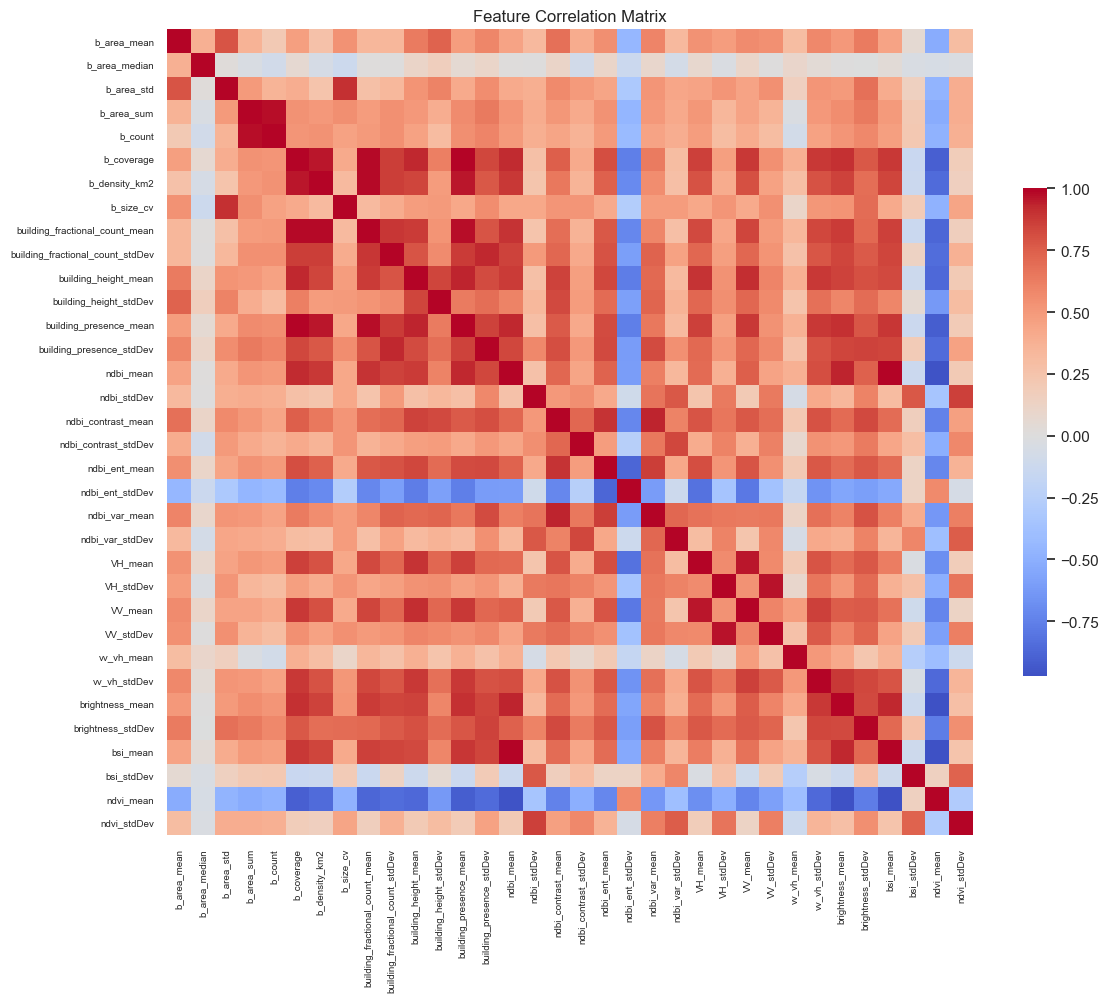

In [6]:
plt.figure(figsize=(12, 10))
sns.heatmap(df[FEATURES].corr(), cmap='coolwarm', center=0, square=True,
            cbar_kws={'shrink': 0.6}, xticklabels=True, yticklabels=True)
plt.title('Feature Correlation Matrix')
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

### 3.4 Do slum and non-slum areas separate on the strongest features?
**Question:** For the six features most associated with the label, how do the class-conditional
distributions overlap? Clear separation suggests strong discriminative power.

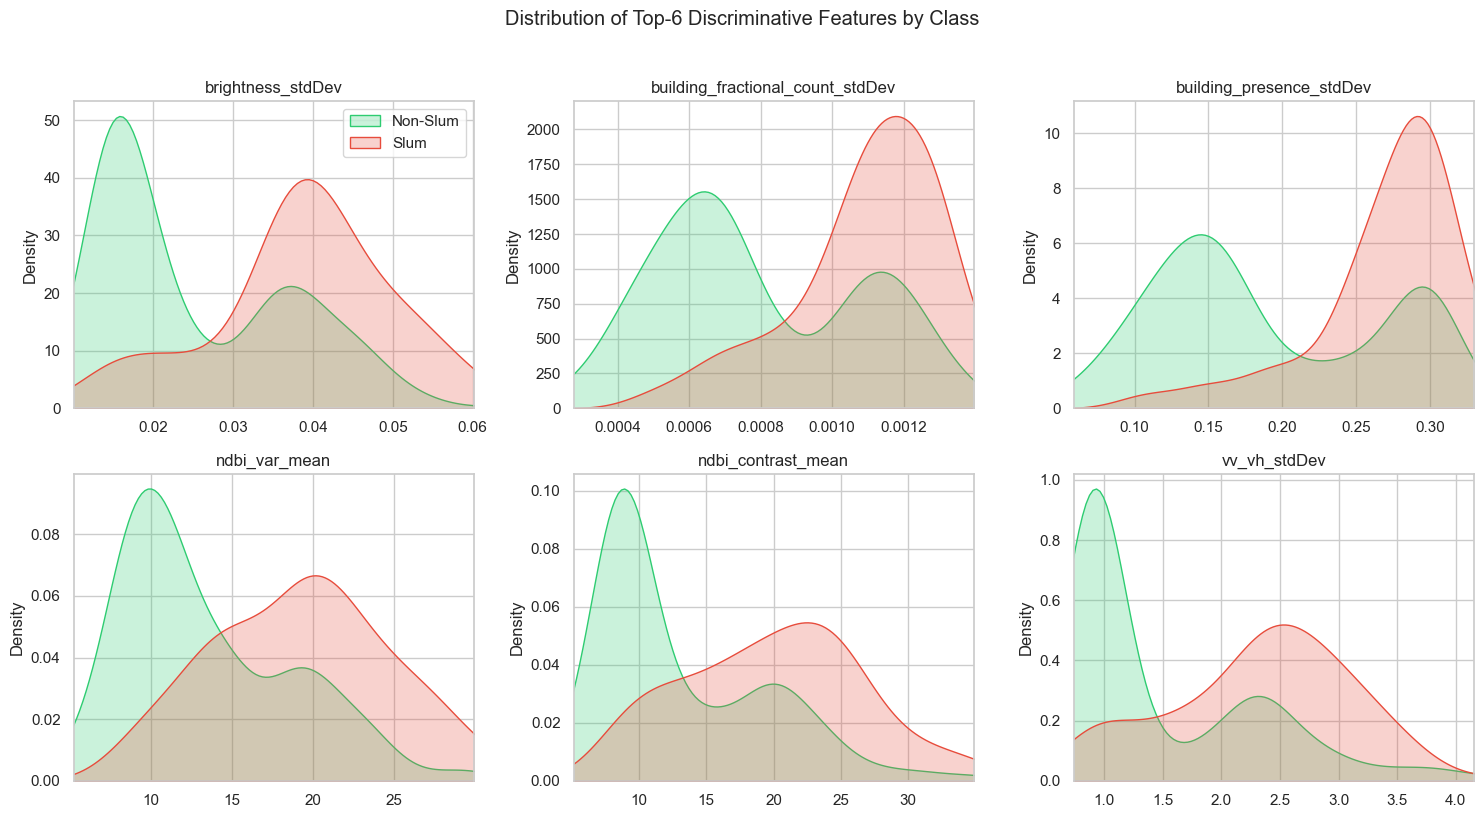

In [7]:
top_feats = corr.abs().sort_values(ascending=False).head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for axi, f in zip(axes.ravel(), top_feats):
    for cls in [0, 1]:
        sns.kdeplot(df.loc[df['slum'] == cls, f], ax=axi, fill=True,
                    color=PALETTE[cls], common_norm=False,
                    label=('Slum' if cls else 'Non-Slum'))
    axi.set_title(f)
    axi.set_xlabel('')
    axi.set_xlim(df[f].quantile(0.01), df[f].quantile(0.99))
axes.ravel()[0].legend()
fig.suptitle('Distribution of Top-6 Discriminative Features by Class', y=1.02)
plt.tight_layout()
plt.show()

### 3.5 Where do slums sit in spectral space?
**Question:** Plotting vegetation (NDVI) against built-up intensity (NDBI), do slum areas
occupy a distinct region — typically denser built-up and lower vegetation?

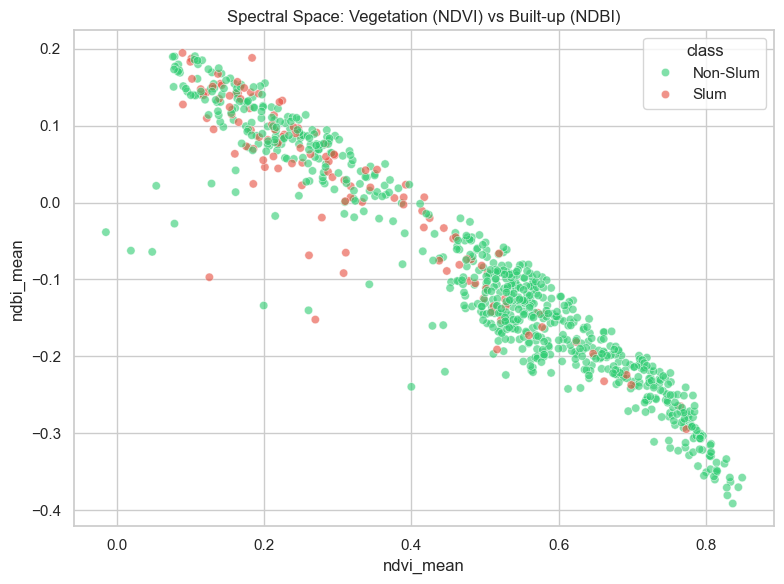

In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='ndvi_mean', y='ndbi_mean', hue='slum', alpha=0.6, palette=PALETTE)
plt.title('Spectral Space: Vegetation (NDVI) vs Built-up (NDBI)')
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Non-Slum', 'Slum'], title='class')
plt.tight_layout()
plt.show()

### 3.6 Do feature scales shift between cities?
**Question:** Do key features such as building density and built-up index have different
ranges across cities? Differences here are the reason we validate city-by-city rather than
with a random split.

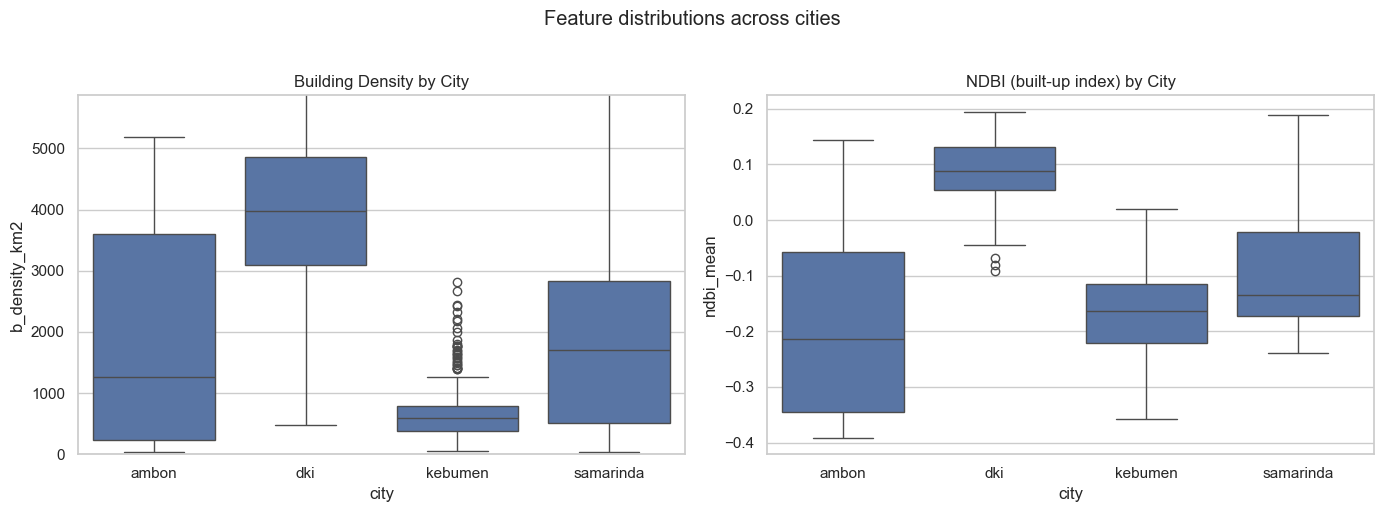

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='city', y='b_density_km2', ax=ax[0])
ax[0].set_ylim(0, df['b_density_km2'].quantile(0.97))
ax[0].set_title('Building Density by City')
sns.boxplot(data=df, x='city', y='ndbi_mean', ax=ax[1])
ax[1].set_title('NDBI (built-up index) by City')
fig.suptitle('Feature distributions across cities', y=1.02)
plt.tight_layout()
plt.show()

### 3.7 Geospatial overview
**Question:** Where are the slum kelurahan located, and how does building density vary across
space? Mapping the labels and a key feature gives a geographic feel for the problem before
modeling. Maps require the kelurahan boundary polygons; if the file is not found, these cells
are skipped automatically.

In [10]:
# Load kelurahan polygons and join them to the feature table for mapping.
gdf = None
try:
    import geopandas as gpd
    from pathlib import Path

    GEO_CANDIDATES = [
        '../data/processed/labels.geojson',
        '../data/processed/kelurahan.geojson',
        '../data/raw/labels.geojson',
        '../data/labels.geojson',
    ]
    geo_path = next((p for p in GEO_CANDIDATES if Path(p).exists()), None)
    if geo_path is None:
        print('Boundary polygons not found in expected locations; map cells will be skipped.')
        print('Set geo_path manually to your kelurahan boundary file to enable maps.')
    elif 'unit_id' not in df.columns:
        print('unit_id missing from feature table; cannot join polygons.')
    else:
        raw = gpd.read_file(geo_path)
        if 'unit_id' not in raw.columns:
            print(f'unit_id missing from {geo_path}; cannot join polygons.')
        else:
            gdf = raw[['unit_id', 'geometry']].merge(df, on='unit_id', how='inner')
            print(f'Loaded and joined {len(gdf)} polygons from {geo_path}.')
except ImportError:
    print('geopandas not installed; run `pip install geopandas contextily` to enable maps.')


def add_basemap(ax):
    # Optional CartoDB basemap; silently ignored if contextily/network is unavailable.
    try:
        import contextily as cx
        cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, attribution_size=5)
    except Exception:
        pass

Loaded and joined 828 polygons from ../data/processed/labels.geojson.


**Map 1 — Slum vs non-slum kelurahan.** Each city is shown in its own panel; red polygons are
slums, green are non-slums.

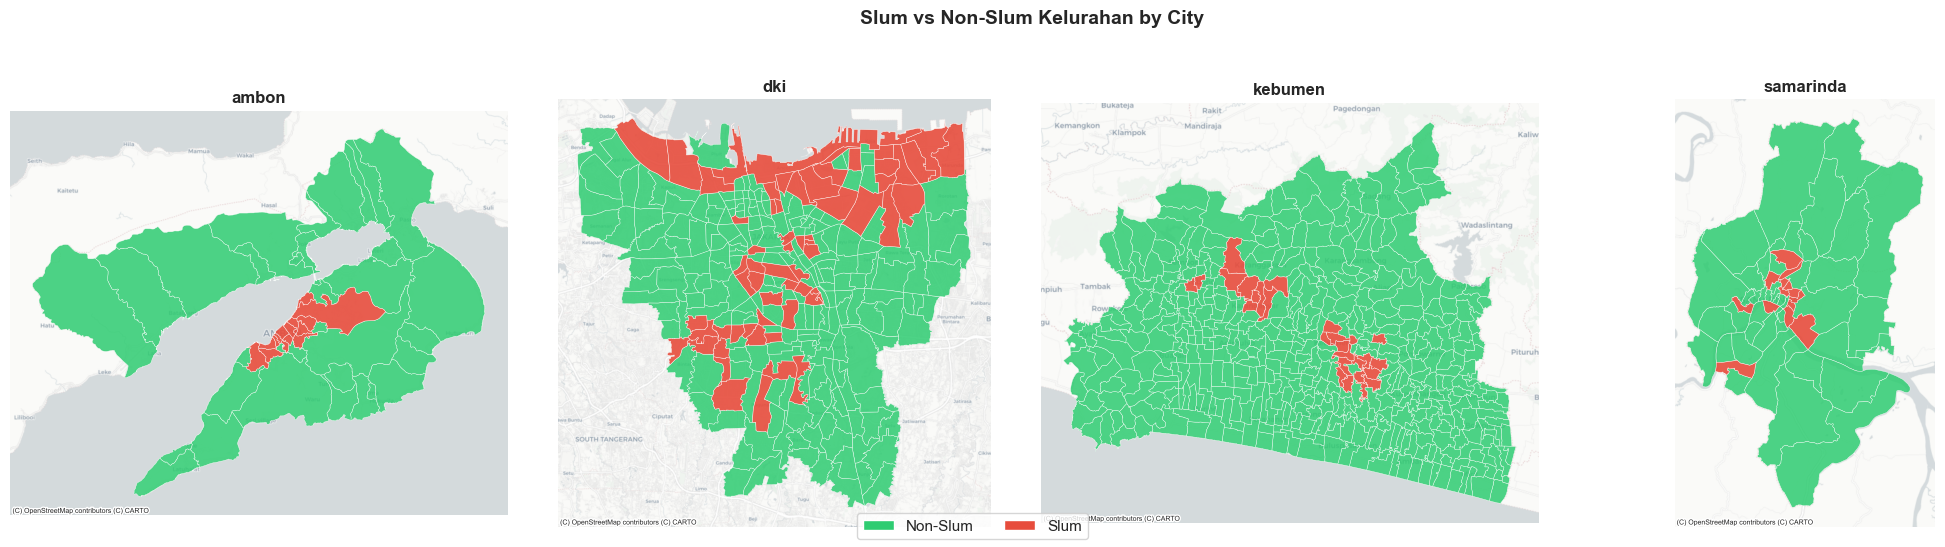

In [11]:
if gdf is not None:
    cities = sorted(gdf['city'].unique())
    fig, axes = plt.subplots(1, len(cities), figsize=(5.2 * len(cities), 5.2))
    axes = np.atleast_1d(axes)
    for ax, c in zip(axes, cities):
        sub = gdf[gdf['city'] == c].to_crs(3857)
        sub[sub['slum'] == 0].plot(ax=ax, color=PALETTE[0], edgecolor='white',
                                   linewidth=0.3, alpha=0.85)
        sub[sub['slum'] == 1].plot(ax=ax, color=PALETTE[1], edgecolor='white',
                                   linewidth=0.3, alpha=0.9)
        add_basemap(ax)
        ax.set_title(c, fontweight='bold')
        ax.axis('off')
    legend_elems = [Patch(facecolor=PALETTE[0], label='Non-Slum'),
                    Patch(facecolor=PALETTE[1], label='Slum')]
    fig.legend(handles=legend_elems, loc='lower center', ncol=2, frameon=True)
    fig.suptitle('Slum vs Non-Slum Kelurahan by City', y=1.03, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Map skipped (no geometry available).')

**Map 2 — Building density.** A shared color scale (built-up density per km²) makes the
spatial pattern comparable across cities and against the slum map above.

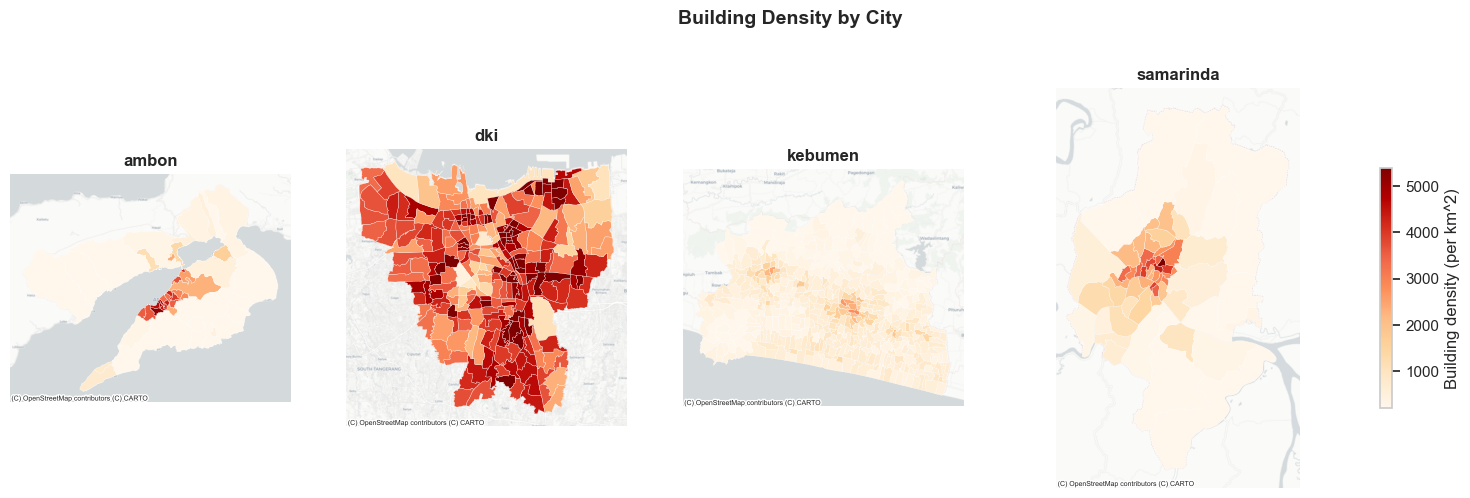

In [12]:
if gdf is not None:
    cities = sorted(gdf['city'].unique())
    vmin = float(gdf['b_density_km2'].quantile(0.05))
    vmax = float(gdf['b_density_km2'].quantile(0.95))
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = 'OrRd'

    fig, axes = plt.subplots(1, len(cities), figsize=(5.2 * len(cities), 5.2))
    axes = np.atleast_1d(axes)
    for ax, c in zip(axes, cities):
        sub = gdf[gdf['city'] == c].to_crs(3857)
        sub.plot(column='b_density_km2', ax=ax, cmap=cmap, norm=norm,
                 edgecolor='white', linewidth=0.2)
        add_basemap(ax)
        ax.set_title(c, fontweight='bold')
        ax.axis('off')
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=axes, shrink=0.6, label='Building density (per km^2)')
    fig.suptitle('Building Density by City', y=1.03, fontsize=14, fontweight='bold')
    plt.show()
else:
    print('Map skipped (no geometry available).')

## 4. Validation Strategy: Leave-One-City-Out (LOCO)

Kelurahan within the same city share environmental and morphological characteristics, and
feature scales shift between cities (Section 3.6). To measure performance on a genuinely
**new city**, we use Leave-One-City-Out cross-validation: the model trains on three cities
and is evaluated on the fourth, repeating until every city has served as the evaluation set
once. Class weights are computed from the training cities of each fold. The table below shows
the composition of each fold.

In [13]:
rows = []
for tr, te in LeaveOneGroupOut().split(np.zeros(len(y)), y, groups):
    rows.append({
        'eval_city': groups[te][0],
        'train_cities': ', '.join(sorted(np.unique(groups[tr]))),
        'n_train': len(tr), 'slum_train': int(y[tr].sum()),
        'n_eval': len(te), 'slum_eval': int(y[te].sum()),
    })
pd.DataFrame(rows)

,eval_city,train_cities,n_train,slum_train,n_eval,slum_eval
0,ambon,"dki, kebumen, samarinda",778,103,50,15
1,dki,"ambon, kebumen, samarinda",567,56,261,62
2,kebumen,"ambon, dki, samarinda",370,91,458,27
3,samarinda,"ambon, dki, kebumen",769,104,59,14


## 5. Model & Cross-City Prediction

The model is a compact pipeline: median imputation followed by an XGBoost classifier (trees
are scale-invariant, so no feature scaling is required). Parameters are deliberately
conservative to suit a small dataset. For each fold, `scale_pos_weight` is set from the
training cities to reflect their class balance, and the held-out city receives predictions
from a model that never saw it during training. Collecting these held-out predictions for all
four cities yields one prediction per kelurahan.

In [14]:
def make_xgb(scale_pos_weight, **params):
    cfg = dict(
        n_estimators=400, max_depth=3, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0, min_child_weight=2,
        scale_pos_weight=scale_pos_weight, objective='binary:logistic',
        eval_metric='aucpr', n_jobs=-1, random_state=RANDOM_STATE, verbosity=0,
    )
    cfg.update(params)
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', XGBClassifier(**cfg)),
    ])


def loco_oof(feature_cols, params=None):
    # Each city is predicted by a model trained on the other three cities.
    # scale_pos_weight is recomputed from the training cities of each fold.
    params = params or {}
    X = df[feature_cols]
    oof = np.zeros(len(y))
    for tr, te in LeaveOneGroupOut().split(X, y, groups):
        spw = (y[tr] == 0).sum() / max((y[tr] == 1).sum(), 1)
        model = make_xgb(spw, **params).fit(X.iloc[tr], y[tr])
        oof[te] = model.predict_proba(X.iloc[te])[:, 1]
    return oof


def per_city_metrics(oof):
    out = []
    for c in sorted(np.unique(groups)):
        m = groups == c
        out.append({
            'city': c, 'n': int(m.sum()), 'slum': int(y[m].sum()),
            'PR_AUC': average_precision_score(y[m], oof[m]),
            'ROC_AUC': roc_auc_score(y[m], oof[m]),
        })
    return pd.DataFrame(out)


oof = loco_oof(FEATURES)

## 6. Performance Metrics

Because the classes are imbalanced (~14% slums), **PR-AUC** (area under the precision-recall
curve) is the primary ranking metric, complemented by ROC-AUC. The lift over the prevalence
baseline shows how much better the model ranks slums than chance. A per-city breakdown
accompanies the pooled figure so performance can be read city by city.

In [15]:
pr_auc = average_precision_score(y, oof)
roc_auc = roc_auc_score(y, oof)
baseline = float(y.mean())

display(pd.DataFrame({
    'metric': ['PR-AUC (LOCO)', 'ROC-AUC (LOCO)',
               'Baseline PR-AUC (prevalence)', 'Lift over baseline (x)'],
    'value': [round(pr_auc, 4), round(roc_auc, 4),
              round(baseline, 4), round(pr_auc / baseline, 2)],
}))
per_city_metrics(oof).round(3)

,metric,value
0,PR-AUC (LOCO),0.2565
1,ROC-AUC (LOCO),0.7410
2,Baseline PR-AUC (prevalence),0.1425
3,Lift over baseline (x),1.8000


,city,n,slum,PR_AUC,ROC_AUC
0,ambon,50,15,0.645,0.851
1,dki,261,62,0.251,0.498
2,kebumen,458,27,0.470,0.773
3,samarinda,59,14,0.437,0.727


## 7. Classification Threshold & Detailed Report

To convert ranked probabilities into slum/non-slum decisions we select the threshold that
maximizes F1 on the cross-validated predictions, which prioritizes catching slums under class
imbalance. We then print the **full** classification report (precision, recall, F1, support
for both classes, plus overall accuracy), followed by the two primary headline metrics:

- **F1 (slum class)** — the harmonic mean of precision and recall on the minority class; the
  most informative single number when the classes are imbalanced.
- **Accuracy** — the overall share of correct predictions across all kelurahan.

In [16]:
prec, rec, thr = precision_recall_curve(y, oof)
f1_curve = 2 * prec * rec / (prec + rec + 1e-12)
best = int(np.nanargmax(f1_curve[:-1]))
best_threshold = float(thr[best])
y_pred = (oof >= best_threshold).astype(int)

display(pd.Series({'operating_threshold': round(best_threshold, 3),
                   'max_F1': round(float(f1_curve[best]), 3)}).to_frame('value'))

# Full classification report: precision / recall / f1 / support for each class + accuracy.
report_df = pd.DataFrame(classification_report(
    y, y_pred, target_names=['Non-Slum', 'Slum'], output_dict=True)).T.round(3)
display(report_df)

,value
operating_threshold,0.113
max_F1,0.429


,precision,recall,f1-score,support
Non-Slum,0.957,0.666,0.786,710.000
Slum,0.290,0.822,0.429,118.000
accuracy,0.688,0.688,0.688,0.688
macro avg,0.624,0.744,0.607,828.000
weighted avg,0.862,0.688,0.735,828.000


In [17]:
# All evaluation metrics in one table.
acc = accuracy_score(y, y_pred)
prec_slum = precision_score(y, y_pred, pos_label=1)
rec_slum = recall_score(y, y_pred, pos_label=1)
f1_slum = f1_score(y, y_pred, pos_label=1)
f1_macro = f1_score(y, y_pred, average='macro')

all_metrics = pd.DataFrame({
    'metric': ['Accuracy', 'Precision (Slum)', 'Recall (Slum)', 'F1 (Slum)',
               'F1 (macro)', 'PR-AUC', 'ROC-AUC'],
    'value': [round(acc, 4), round(prec_slum, 4), round(rec_slum, 4),
              round(f1_slum, 4), round(f1_macro, 4), round(pr_auc, 4), round(roc_auc, 4)],
})
display(all_metrics)

# Primary headline metrics for this imbalanced task.
print('Primary metrics')
print(f'  F1 (Slum)  : {f1_slum:.3f}  -> balances precision and recall on the minority class')
print(f'  Accuracy   : {acc:.3f}  -> overall share of correct predictions')

,metric,value
0,Accuracy,0.6884
1,Precision (Slum),0.2904
2,Recall (Slum),0.8220
3,F1 (Slum),0.4292
4,F1 (macro),0.6075
5,PR-AUC,0.2565
6,ROC-AUC,0.7410


Primary metrics
  F1 (Slum)  : 0.429  -> balances precision and recall on the minority class
  Accuracy   : 0.688  -> overall share of correct predictions


## 8. Evaluation Plots

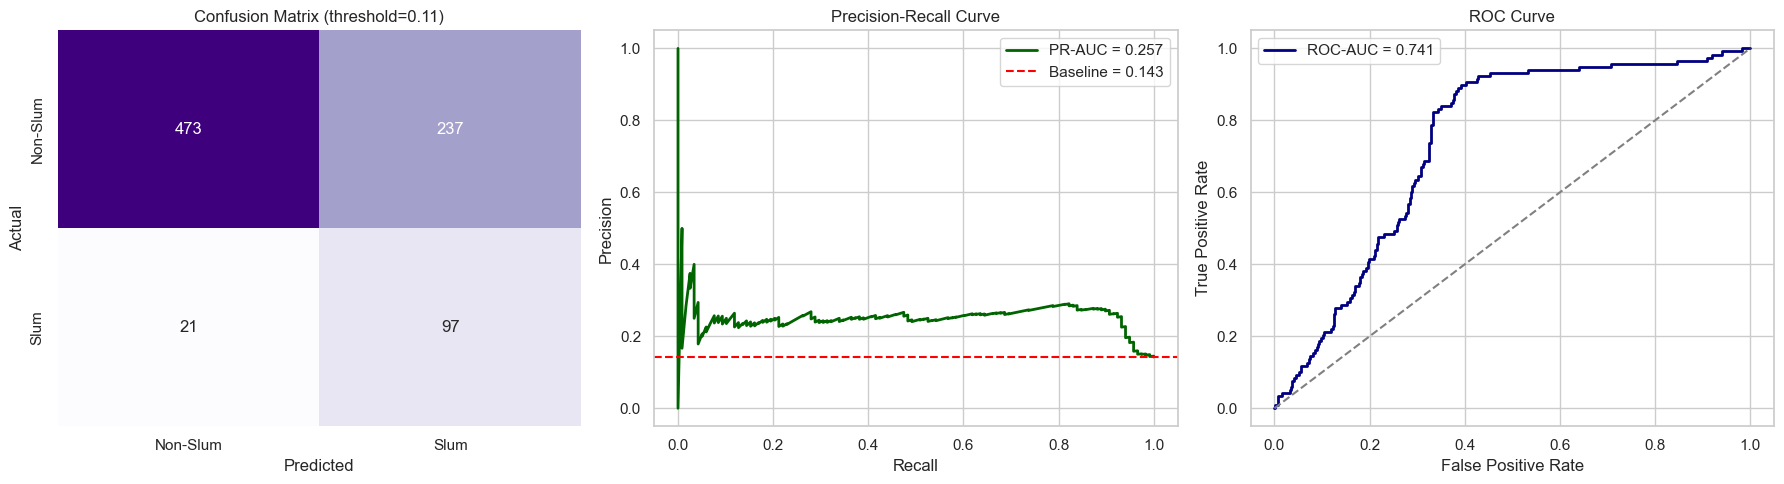

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Non-Slum', 'Slum'], yticklabels=['Non-Slum', 'Slum'], ax=ax[0])
ax[0].set_title(f'Confusion Matrix (threshold={best_threshold:.2f})')
ax[0].set_xlabel('Predicted'); ax[0].set_ylabel('Actual')

ax[1].plot(rec, prec, color='darkgreen', lw=2, label=f'PR-AUC = {pr_auc:.3f}')
ax[1].axhline(baseline, ls='--', color='red', label=f'Baseline = {baseline:.3f}')
ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precision')
ax[1].set_title('Precision-Recall Curve'); ax[1].legend()

fpr, tpr, _ = roc_curve(y, oof)
ax[2].plot(fpr, tpr, color='navy', lw=2, label=f'ROC-AUC = {roc_auc:.3f}')
ax[2].plot([0, 1], [0, 1], ls='--', color='grey')
ax[2].set_xlabel('False Positive Rate'); ax[2].set_ylabel('True Positive Rate')
ax[2].set_title('ROC Curve'); ax[2].legend()

plt.tight_layout()
plt.show()

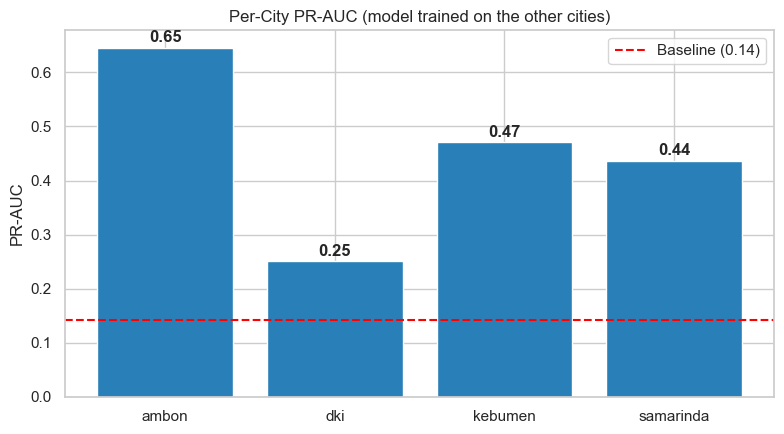

In [19]:
pc = per_city_metrics(oof)
plt.figure(figsize=(8, 4.5))
plt.bar(pc['city'], pc['PR_AUC'], color='#2980b9')
plt.axhline(baseline, ls='--', color='red', label=f'Baseline ({baseline:.2f})')
for i, v in enumerate(pc['PR_AUC']):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center', fontweight='bold')
plt.title('Per-City PR-AUC (model trained on the other cities)')
plt.ylabel('PR-AUC'); plt.legend()
plt.tight_layout()
plt.show()

**Map 3 — Predicted slum risk.** The cross-validated slum probability for each kelurahan,
mapped per city. Brighter areas are higher predicted risk and can be compared directly with
the ground-truth slum map in Section 3.7.

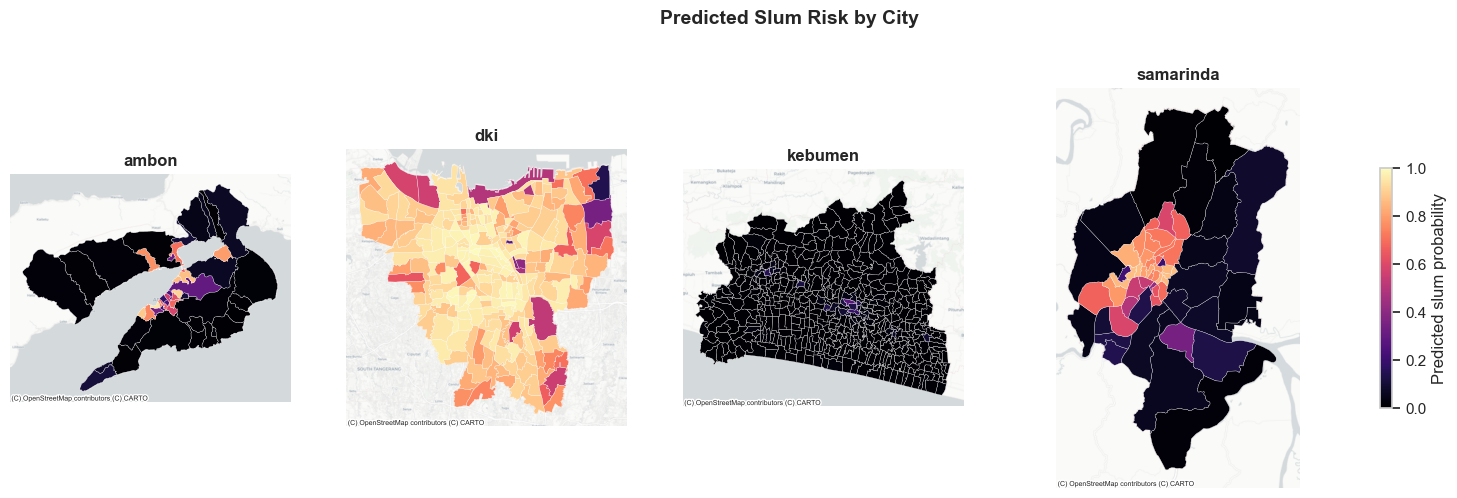

In [20]:
if gdf is not None:
    prob_by_id = pd.Series(oof, index=df['unit_id'])
    gpred = gdf.copy()
    gpred['slum_probability'] = gpred['unit_id'].map(prob_by_id)

    cities = sorted(gpred['city'].unique())
    norm = Normalize(vmin=0.0, vmax=1.0)
    cmap = 'magma'
    fig, axes = plt.subplots(1, len(cities), figsize=(5.2 * len(cities), 5.2))
    axes = np.atleast_1d(axes)
    for ax, c in zip(axes, cities):
        sub = gpred[gpred['city'] == c].to_crs(3857)
        sub.plot(column='slum_probability', ax=ax, cmap=cmap, norm=norm,
                 edgecolor='white', linewidth=0.2)
        add_basemap(ax)
        ax.set_title(c, fontweight='bold')
        ax.axis('off')
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=axes, shrink=0.6, label='Predicted slum probability')
    fig.suptitle('Predicted Slum Risk by City', y=1.03, fontsize=14, fontweight='bold')
    plt.show()
else:
    print('Map skipped (no geometry available).')

## 9. Feature Importance (SHAP)

For interpretation, a model is fit on all kelurahan and explained with SHAP values, which
attribute each prediction to its features. The summary plot ranks features by overall impact
and shows the direction of their effect across all data sources.

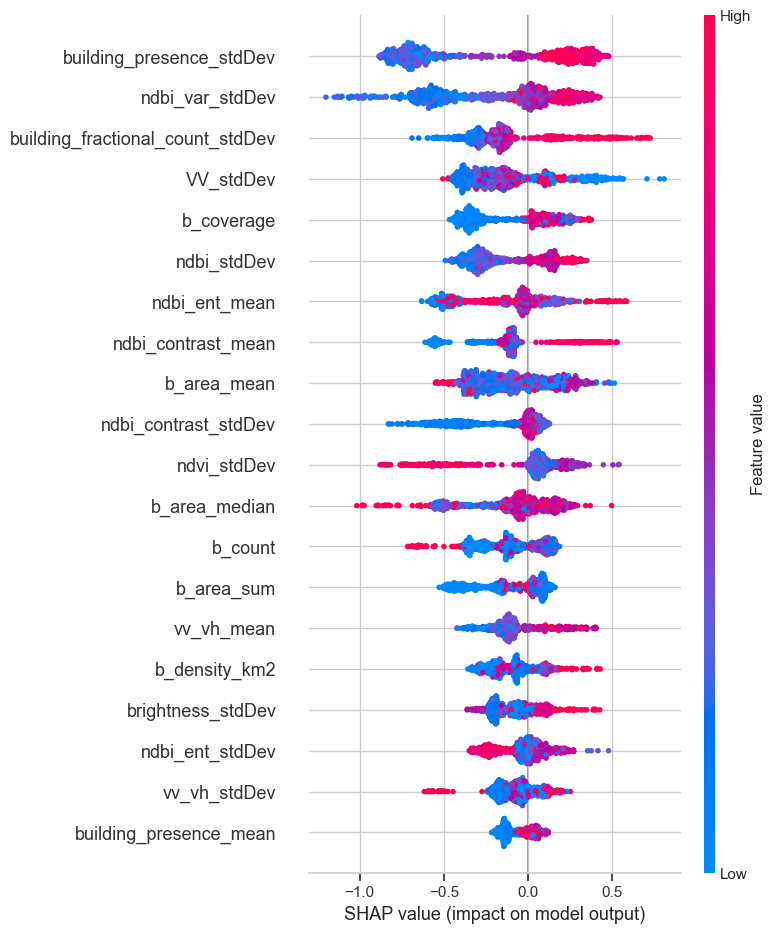

In [21]:
spw_all = (y == 0).sum() / (y == 1).sum()
final_model = make_xgb(spw_all).fit(df[FEATURES], y)

clf = final_model.named_steps['clf']
X_imputed = pd.DataFrame(final_model.named_steps['imputer'].transform(df[FEATURES]),
                         columns=FEATURES)
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_imputed)
shap.summary_plot(shap_values, X_imputed, max_display=20)

## 10. Data Source Contribution

How much do the spectral (Sentinel-2) and radar (Sentinel-1) sources add on top of the
building-footprint features alone? Both feature sets are evaluated under the identical LOCO
protocol so the comparison is on equal footing.

In [22]:
oof_building = loco_oof(CORE_BUILDING)
ablation = pd.DataFrame([
    {'feature_set': 'Building footprint only', 'n_features': len(CORE_BUILDING),
     'PR_AUC': average_precision_score(y, oof_building),
     'ROC_AUC': roc_auc_score(y, oof_building)},
    {'feature_set': 'All features (fusion)', 'n_features': len(FEATURES),
     'PR_AUC': pr_auc, 'ROC_AUC': roc_auc},
]).round(4)
ablation['PR_AUC_gain'] = (ablation['PR_AUC'] - ablation['PR_AUC'].iloc[0]).round(4)
ablation

,feature_set,n_features,PR_AUC,ROC_AUC,PR_AUC_gain
0,Building footprint only,14,0.2555,0.7441,0.000
1,All features (fusion),34,0.2565,0.7410,0.001


## 11. Hyperparameter Tuning Comparison (Optional)

This section compares the fixed, pre-registered hyperparameters against a nested randomized
search that tunes the model **inside** each training split and evaluates on the held-out city.
On a dataset of this size, well-chosen fixed parameters are often competitive with tuning.
Run this cell only when you want the comparison, as it is slower.

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'clf__n_estimators': [300, 400],
    'clf__max_depth': [2, 3, 4],
    'clf__learning_rate': [0.01, 0.03, 0.05],
    'clf__subsample': [0.8, 1.0],
    'clf__colsample_bytree': [0.8, 1.0],
    'clf__min_child_weight': [2, 4],
} 


def nested_loco_oof(feature_cols):
    X = df[feature_cols]
    oof_t = np.zeros(len(y))
    fold_best = []
    for tr, te in LeaveOneGroupOut().split(X, y, groups):
        eval_city = groups[te][0]
        spw = (y[tr] == 0).sum() / max((y[tr] == 1).sum(), 1)
        search = GridSearchCV(
            make_xgb(spw, n_jobs=1), param_grid, scoring='average_precision',
            cv=GroupKFold(n_splits=3), n_jobs=-1,
        )
        search.fit(X.iloc[tr], y[tr], groups=groups[tr])
        oof_t[te] = search.best_estimator_.predict_proba(X.iloc[te])[:, 1]
        bp = {k.replace('clf__', ''): v for k, v in search.best_params_.items()}
        bp['eval_city'] = eval_city
        bp['inner_PR_AUC'] = round(float(search.best_score_), 4)
        fold_best.append(bp)
    return oof_t, pd.DataFrame(fold_best)


oof_tuned, best_params_per_fold = nested_loco_oof(FEATURES)

param_cols = ['eval_city', 'n_estimators', 'max_depth', 'learning_rate',
              'subsample', 'colsample_bytree', 'min_child_weight', 'inner_PR_AUC']
print('Best parameters per held-out city')
display(best_params_per_fold[[c for c in param_cols if c in best_params_per_fold.columns]])

pr_auc_tuned = average_precision_score(y, oof_tuned)
roc_auc_tuned = roc_auc_score(y, oof_tuned)
display(pd.DataFrame({
    'approach': ['Fixed params (Section 5)', 'Nested-CV tuned'],
    'PR_AUC': [round(pr_auc, 4), round(pr_auc_tuned, 4)],
    'ROC_AUC': [round(roc_auc, 4), round(roc_auc_tuned, 4)],
}))

prec_t, rec_t, thr_t = precision_recall_curve(y, oof_tuned)
f1_curve_t = 2 * prec_t * rec_t / (prec_t + rec_t + 1e-12)
best_t = int(np.nanargmax(f1_curve_t[:-1]))
threshold_tuned = float(thr_t[best_t])
y_pred_tuned = (oof_tuned >= threshold_tuned).astype(int)

display(pd.Series({'operating_threshold': round(threshold_tuned, 3),
                   'max_F1': round(float(f1_curve_t[best_t]), 3)}).to_frame('value'))

report_tuned = pd.DataFrame(classification_report(
    y, y_pred_tuned, target_names=['Non-Slum', 'Slum'], output_dict=True)).T.round(3)
display(report_tuned)

acc_t = accuracy_score(y, y_pred_tuned)
all_metrics_tuned = pd.DataFrame({
    'metric': ['Accuracy', 'Precision (Slum)', 'Recall (Slum)', 'F1 (Slum)',
               'F1 (macro)', 'PR-AUC', 'ROC-AUC'],
    'value': [round(acc_t, 4),
              round(precision_score(y, y_pred_tuned, pos_label=1), 4),
              round(recall_score(y, y_pred_tuned, pos_label=1), 4),
              round(f1_score(y, y_pred_tuned, pos_label=1), 4),
              round(f1_score(y, y_pred_tuned, average='macro'), 4),
              round(pr_auc_tuned, 4), round(roc_auc_tuned, 4)],
})
display(all_metrics_tuned)

print('Primary metrics (tuned model)')
print(f'  F1 (Slum)  : {f1_score(y, y_pred_tuned, pos_label=1):.3f}')
print(f'  Accuracy   : {acc_t:.3f}')

Best parameters per held-out city


,eval_city,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,inner_PR_AUC
0,ambon,300,4,0.05,1.0,1.0,4,0.3602
1,dki,300,2,0.01,0.8,0.8,4,0.5559
2,kebumen,300,2,0.01,0.8,0.8,2,0.5521
3,samarinda,400,3,0.01,0.8,1.0,2,0.4540


,approach,PR_AUC,ROC_AUC
0,Fixed params (Section 5),0.2565,0.7410
1,Nested-CV tuned,0.2861,0.7382


,value
operating_threshold,0.176
max_F1,0.430


,precision,recall,f1-score,support
Non-Slum,0.961,0.658,0.781,710.000
Slum,0.289,0.839,0.430,118.000
accuracy,0.684,0.684,0.684,0.684
macro avg,0.625,0.748,0.606,828.000
weighted avg,0.865,0.684,0.731,828.000


,metric,value
0,Accuracy,0.6836
1,Precision (Slum),0.2895
2,Recall (Slum),0.8390
3,F1 (Slum),0.4304
4,F1 (macro),0.6057
5,PR-AUC,0.2861
6,ROC-AUC,0.7382


Primary metrics (tuned model)
  F1 (Slum)  : 0.430
  Accuracy   : 0.684


## 12. Inference on New Areas

`predict_new_area` scores any dataframe that shares the feature columns and returns the slum
probability and the thresholded prediction. To estimate performance on a new region, apply it
to data from a city outside the training set. The demo below scores a few sample rows to show
the output format.

In [29]:
def predict_new_area(df_new, model=final_model, features=FEATURES, threshold=best_threshold):
    proba = model.predict_proba(df_new[features])[:, 1]
    out = df_new.copy()
    out['slum_probability'] = proba
    out['slum_prediction'] = (proba >= threshold).astype(int)
    return out


demo = predict_new_area(df.sample(5, random_state=10))
demo[['unit_id', 'city', 'slum', 'slum_probability', 'slum_prediction']]

,unit_id,city,slum,slum_probability,slum_prediction
339,kebumen_0028,kebumen,0,0.028754,0
68,dki_0018,dki,0,0.257019,1
264,dki_0214,dki,0,0.266105,1
278,dki_0228,dki,0,0.291186,1
529,kebumen_0218,kebumen,1,0.887415,1
